In [3]:
# imports 
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from modules.layer import ABiMap

from sklearn.preprocessing import LabelEncoder

from spd_learn.functional import bimap_transform, orthogonal_polar_factor, log_euclidean_geodesic
from spd_learn.modules    import ReEig, LogEig
from spd_learn.models     import SPDNet

import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from pyriemann.estimation import Covariances

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

Device : cuda


In [4]:
class ABiMapNet(nn.Module):
    """SPDNet with a single ABiMap layer.

    Args:
        n         : input SPD matrix dimension
        m_init    : initial output dimension of ABiMap
        m_max     : maximum output dimension of ABiMap (≤ n)
        n_classes : number of output classes
        **kwargs  : passed to ABiMap (thresh_hi, thresh_lo, verbose)
    """

    def __init__(self, n, m_init, m_max, n_classes, **kwargs):
        super().__init__()
        self.bimap  = ABiMap(n=n, m_init=m_init, m_max=m_max, **kwargs)
        self.reeig  = ReEig()
        self.logeig = LogEig(flatten=True)
        self.fc     = nn.Linear(m_max * (m_max + 1) // 2, n_classes)

    def forward(self, X):
        return self.fc(self.logeig(self.reeig(self.bimap(X))))

    def get_alpha(self):   return self.bimap.get_alpha()
    def get_m(self):       return self.bimap.get_m()
    def get_final_m(self): return self.bimap.get_final_m()

**Training — Subject 1, BNCI2014-001 (4 classes)**
for this example : Training is on session 1 called "0train" and Test is on session 2 called "1test"

In [5]:
SUBJECT    = 3
CLASSES    = ['left_hand', 'right_hand', 'feet', 'tongue']

dataset  = BNCI2014_001()
paradigm = MotorImagery(events=CLASSES, n_classes=len(CLASSES), fmin=8, fmax=32)

X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=[SUBJECT])

mask = meta['session'] == '0train'
X_tr_cov = Covariances(estimator='scm').fit_transform(X_raw[mask])
y_tr     = LabelEncoder().fit_transform(y_raw[mask])

mask = meta['session'] == '1test'
X_te_cov = Covariances(estimator='scm').fit_transform(X_raw[mask])
y_te     = LabelEncoder().fit_transform(y_raw[mask])

n_chans = X_tr_cov.shape[1]

X_train = torch.tensor(X_tr_cov, dtype=torch.float32).to(device)
y_train = torch.tensor(y_tr,     dtype=torch.long).to(device)
X_test  = torch.tensor(X_te_cov, dtype=torch.float32).to(device)
y_test  = torch.tensor(y_te,     dtype=torch.long).to(device)

print(f"Train / Test : {len(X_train)} / {len(X_test)}")

Train / Test : 288 / 288


In [21]:
BATCH_SIZE = 64

M_INIT     = 2
M_MAX      = 4 * len(CLASSES)

LR = 1e-2

model = ABiMapNet(
    n=n_chans, m_init=M_INIT, m_max=M_MAX,
    n_classes=len(CLASSES), tau=0.5,
    thresh_hi=0.80, thresh_lo=0.20, verbose=True
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [22]:
N_EPOCHS   = 2000

logs = []
for epoch in range(N_EPOCHS):
    # training 
    model.train()
    optimizer.zero_grad()
    idx  = torch.randperm(len(X_train), device=device)[:BATCH_SIZE]
    loss = criterion(model(X_train[idx]), y_train[idx])
    loss.backward()
    optimizer.step()

    # Evaluation 
    model.eval()
    with torch.no_grad():
        acc_tr = (model(X_train).argmax(1) == y_train).float().mean().item()
        acc_te = (model(X_test).argmax(1)  == y_test ).float().mean().item()

    logs.append({
        'epoch'     : epoch,
        'train_loss': loss.item(),
        'acc_train' : acc_tr,
        'acc_test'  : acc_te,
        'alpha'     : model.get_alpha(),
        'm'         : model.get_m(),
    })

    if epoch % 100 == 0:
        print(f"  Epoch {epoch:5d} | loss={loss.item():.4f} | acc_tr={acc_tr:.3f} | "
              f"acc_test={acc_te:.3f} | m={model.get_m()} | alpha={model.get_alpha():.3f}")

# Final Evaluation
model.eval()
with torch.no_grad():
    acc_final = (model(X_test).argmax(1).cpu().numpy() == y_te).mean()

print(f"\n  m={model.get_m()} | m_final={model.get_final_m()} | "
      f"alpha={model.get_alpha():.3f} | acc_test={acc_final:.4f}")

  Epoch     0 | loss=1.4035 | acc_tr=0.253 | acc_test=0.250 | m=2 | alpha=0.505
  [EXPAND] m → 3 | alpha = 0.500
  Epoch   100 | loss=1.1566 | acc_tr=0.514 | acc_test=0.479 | m=3 | alpha=0.559
  Epoch   200 | loss=0.8840 | acc_tr=0.701 | acc_test=0.608 | m=3 | alpha=0.699
  Epoch   300 | loss=0.7320 | acc_tr=0.677 | acc_test=0.618 | m=3 | alpha=0.783
  [EXPAND] m → 4 | alpha = 0.500
  Epoch   400 | loss=0.5882 | acc_tr=0.774 | acc_test=0.740 | m=4 | alpha=0.671
  [EXPAND] m → 5 | alpha = 0.500
  Epoch   500 | loss=0.4583 | acc_tr=0.726 | acc_test=0.590 | m=5 | alpha=0.526
  Epoch   600 | loss=0.4005 | acc_tr=0.747 | acc_test=0.722 | m=5 | alpha=0.538
  Epoch   700 | loss=0.3767 | acc_tr=0.819 | acc_test=0.740 | m=5 | alpha=0.620
  Epoch   800 | loss=0.2980 | acc_tr=0.708 | acc_test=0.663 | m=5 | alpha=0.724
  Epoch   900 | loss=0.1704 | acc_tr=0.771 | acc_test=0.806 | m=5 | alpha=0.796
  [EXPAND] m → 6 | alpha = 0.500
  Epoch  1000 | loss=0.2880 | acc_tr=0.910 | acc_test=0.816 | m=6 | 

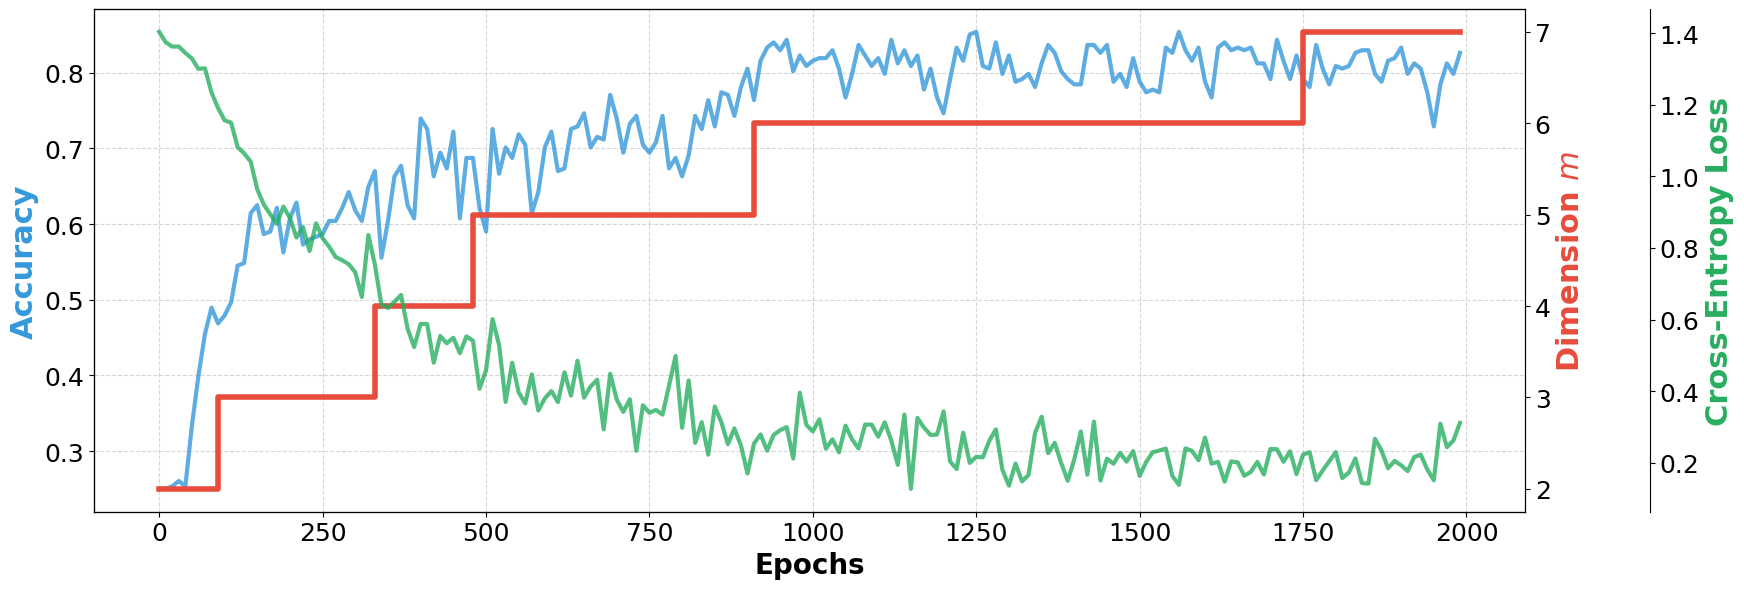

In [23]:
df = pd.DataFrame(logs)

def plot(df):
    fig, ax_acc = plt.subplots(1, 1, figsize=(18, 6))
    ax_m    = ax_acc.twinx()
    ax_loss = ax_acc.twinx()
    ax_loss.spines['right'].set_position(('outward', 90))

    step   = 10
    epochs = df['epoch'].values[::step]
    m      = df['m'].values[::step]
    acc    = df['acc_test'].values[::step]
    loss   = df['train_loss'].values[::step]

    ln2 = ax_acc.plot(epochs, acc,  color='#3498db', alpha=0.8, lw=3, label='Test Accuracy')
    ln1 = ax_m.step( epochs, m,     color='#e74c3c', lw=4, where='post', label='Dimension $m$')
    ax_m.set_yticks(np.arange(int(m.min()), int(m.max()) + 1, 1))
    ln3 = ax_loss.plot(epochs, loss, color='#27ae60', alpha=0.8, lw=3, label='Train Loss')

    ax_acc.set_xlabel("Epochs",              fontsize=20, fontweight='bold')
    ax_acc.set_ylabel("Accuracy",            color='#3498db', fontsize=22, fontweight='bold')
    ax_m.set_ylabel("Dimension $m$",         color='#e74c3c', fontsize=22, fontweight='bold')
    ax_loss.set_ylabel("Cross-Entropy Loss", color='#27ae60', fontsize=22, fontweight='bold')

    ax_acc.tick_params(axis='both', labelsize=18)
    ax_m.tick_params(axis='y',     labelsize=18)
    ax_loss.tick_params(axis='y',  labelsize=18)
    ax_acc.grid(True, which='both', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

plot(df)

The model starts at $m=2$ and expands progressively for 3000 epochs. Each dimension expansion coincides with a jump in test accuracy, confirming that each
additional spatial filter captures genuinely discriminative information.

Here We train an SPDNet with a fixed m=11

In [24]:
M = 11

model     = SPDNet(input_type='cov', n_chans=X_tr_cov.shape[1],
                   subspacedim=M, n_outputs=len(CLASSES)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

# Training 
logs_spdnet = []

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    idx  = torch.randperm(len(X_train), device=device)[:BATCH_SIZE]
    loss = criterion(model(X_train[idx]), y_train[idx])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        acc_tr = (model(X_train[idx]).argmax(1) == y_train[idx]).float().mean().item()
        acc_te = (model(X_test).argmax(1) == y_test).float().mean().item()

    logs_spdnet.append({
        'epoch'     : epoch,
        'train_loss': loss.item(),
        'acc_train' : acc_tr,
        'acc_test'  : acc_te,
    })

    if epoch % 100 == 0:
        print(f"  Epoch {epoch:5d} | loss={loss.item():.4f} | "
              f"acc_tr={acc_tr:.3f} | acc_test={acc_te:.3f}")

# Evaluation
model.eval()
with torch.no_grad():
    acc_final = (model(X_test).argmax(1).cpu().numpy() == y_te).mean()

print(f"\n  m={M} | acc_test={acc_final:.4f}")

  Epoch     0 | loss=1.6510 | acc_tr=0.203 | acc_test=0.229
  Epoch   100 | loss=0.7494 | acc_tr=0.719 | acc_test=0.733
  Epoch   200 | loss=0.3939 | acc_tr=0.906 | acc_test=0.778
  Epoch   300 | loss=0.4638 | acc_tr=0.875 | acc_test=0.823
  Epoch   400 | loss=0.2859 | acc_tr=0.969 | acc_test=0.833
  Epoch   500 | loss=0.2036 | acc_tr=0.938 | acc_test=0.767
  Epoch   600 | loss=0.2289 | acc_tr=0.922 | acc_test=0.837
  Epoch   700 | loss=0.1954 | acc_tr=0.953 | acc_test=0.819
  Epoch   800 | loss=0.2235 | acc_tr=0.906 | acc_test=0.816
  Epoch   900 | loss=0.1874 | acc_tr=0.969 | acc_test=0.792
  Epoch  1000 | loss=0.1406 | acc_tr=0.969 | acc_test=0.819
  Epoch  1100 | loss=0.2492 | acc_tr=0.922 | acc_test=0.812
  Epoch  1200 | loss=0.1814 | acc_tr=0.953 | acc_test=0.837
  Epoch  1300 | loss=0.1987 | acc_tr=0.938 | acc_test=0.812
  Epoch  1400 | loss=0.1051 | acc_tr=1.000 | acc_test=0.833
  Epoch  1500 | loss=0.1144 | acc_tr=0.953 | acc_test=0.819
  Epoch  1600 | loss=0.1839 | acc_tr=0.9

**Comparing the results of the models**

In [25]:
df_abimap = pd.DataFrame(logs)
df_spdnet = pd.DataFrame(logs_spdnet)

acc_abimap = df_abimap['acc_test'].iloc[-1]
acc_spdnet = df_spdnet['acc_test'].iloc[-1]
m_final    = df_abimap['m'].iloc[-1]

print(f"  ABiMap  | m_final={m_final} | acc_test={acc_abimap:.4f}")
print(f"  SPDNet  | m={M}          | acc_test={acc_spdnet:.4f}")

  ABiMap  | m_final=7 | acc_test=0.8229
  SPDNet  | m=11          | acc_test=0.8299


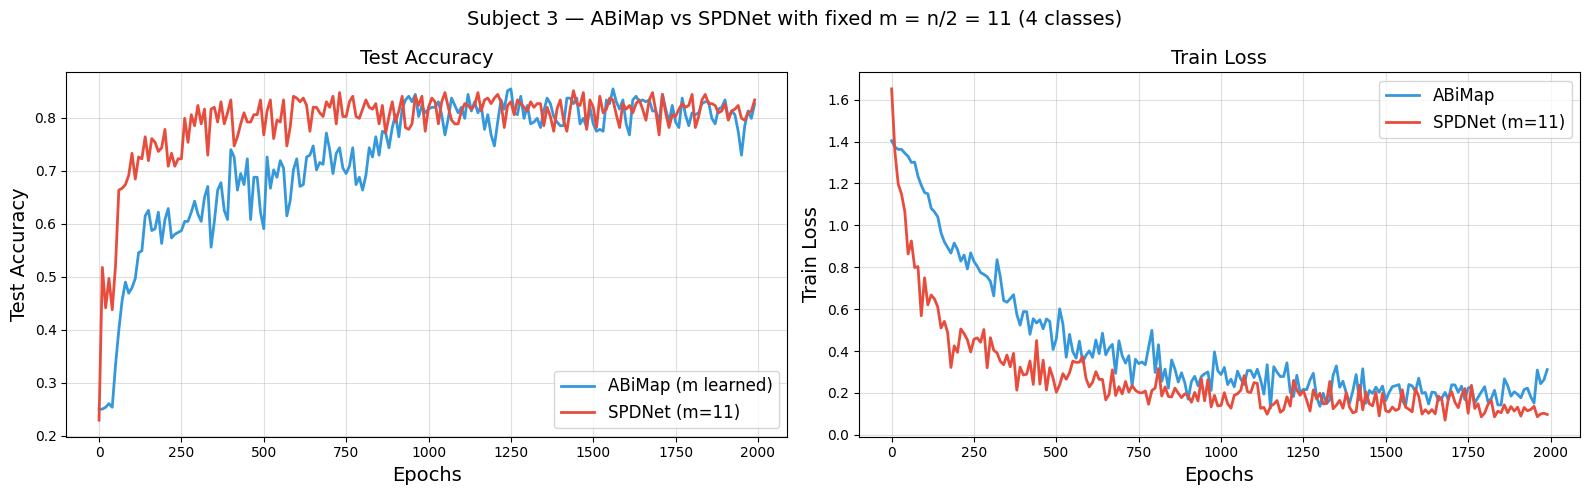

In [26]:
step = 10
df_a = df_abimap.iloc[::step]
df_s = df_spdnet.iloc[::step]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_a['epoch'], df_a['acc_test'], color='#3498db', lw=2, label='ABiMap (m learned)')
ax.plot(df_s['epoch'], df_s['acc_test'], color='#e74c3c', lw=2, label=f'SPDNet (m={M})')
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Test Accuracy', fontsize=14)
ax.set_title('Test Accuracy', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_a['epoch'], df_a['train_loss'], color='#3498db', lw=2, label='ABiMap')
ax.plot(df_s['epoch'], df_s['train_loss'], color='#e74c3c', lw=2, label=f'SPDNet (m={M})')
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Train Loss', fontsize=14)
ax.set_title('Train Loss', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)

plt.suptitle(f'Subject {SUBJECT} — ABiMap vs SPDNet with fixed m = n/2 = 11 (4 classes)', fontsize=14)
plt.tight_layout()
plt.show()

ABiMap (blue) starts from $m=2$ and converges to a test accuracy comparable to SPDNet
with fixed $m=11$ (red). SPDNet converges faster initially since it starts with full capacity, while ABiMap progressively builds up its representational
capacity through dimension expansions. Both models reach similar final performance, but ABiMap does so with $m^*=7$ filters instead of $11$.